In [1]:
 
import os
 
%cd ../..
 
print(f"Current Working Directory: {os.getcwd()}")




/Users/aaronmcdonald/hm-fashion-recommender
Current Working Directory: /Users/aaronmcdonald/hm-fashion-recommender


/opt/anaconda3/envs/myenv/lib/python3.11/site-packages/IPython/core/magics/osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [2]:
# dependicies and imports for data preparation, manipulation and visualization
import pandas as pd
import numpy as np
from datetime import timedelta
import matplotlib.pyplot as plt

# load all the raw data 
'''
customerData = pd.read_csv('/Users/aaronmcdonald/hm-fashion-recommender/data/raw/customers.csv')
articleData = pd.read_csv('/Users/aaronmcdonald/hm-fashion-recommender/data/raw/articles.csv')
transactionsData = pd.read_csv('/Users/aaronmcdonald/hm-fashion-recommender/data/raw/transactions_train .csv')
'''
 
customerData = pd.read_csv('/Users/aaronmcdonald/hm-fashion-recommender/data/raw/customers.csv')
articleData = pd.read_csv('/Users/aaronmcdonald/hm-fashion-recommender/data/raw/articles.csv')
transactionsData = pd.read_csv('/Users/aaronmcdonald/hm-fashion-recommender/data/raw/transactions_train.csv')

 

In [3]:
# merge all the data on to the transactions data
df = pd.merge(transactionsData, customerData, on='customer_id', how='left')
df = pd.merge(df, articleData, on='article_id', how='left')
df.head()

,t_dat,customer_id,article_id,price,sales_channel_id,FN,Active,club_member_status,fashion_news_frequency,age,...,department_name,index_code,index_name,index_group_no,index_group_name,section_no,section_name,garment_group_no,garment_group_name,detail_desc
0,2018-09-20,000058a12d5b43e67d225668fa1f8d618c13dc232df0ca...,663713001,0.050831,2,NaN,NaN,ACTIVE,NONE,24.0,...,Expressive Lingerie,B,Lingeries/Tights,1,Ladieswear,61,Womens Lingerie,1017,"Under-, Nightwear","Lace push-up body with underwired, moulded, pa..."
1,2018-09-20,000058a12d5b43e67d225668fa1f8d618c13dc232df0ca...,541518023,0.030492,2,NaN,NaN,ACTIVE,NONE,24.0,...,Casual Lingerie,B,Lingeries/Tights,1,Ladieswear,61,Womens Lingerie,1017,"Under-, Nightwear","Lace push-up bras with underwired, moulded, pa..."
2,2018-09-20,00007d2de826758b65a93dd24ce629ed66842531df6699...,505221004,0.015237,2,1.0,1.0,ACTIVE,Regularly,32.0,...,Tops Knitwear DS,D,Divided,2,Divided,58,Divided Selected,1003,Knitwear,Jumper in rib-knit cotton with hard-worn detai...
3,2018-09-20,00007d2de826758b65a93dd24ce629ed66842531df6699...,685687003,0.016932,2,1.0,1.0,ACTIVE,Regularly,32.0,...,Campaigns,A,Ladieswear,1,Ladieswear,15,Womens Everyday Collection,1023,Special Offers,V-neck knitted jumper with long sleeves and ri...
4,2018-09-20,00007d2de826758b65a93dd24ce629ed66842531df6699...,685687004,0.016932,2,1.0,1.0,ACTIVE,Regularly,32.0,...,Campaigns,A,Ladieswear,1,Ladieswear,15,Womens Everyday Collection,1023,Special Offers,V-neck knitted jumper with long sleeves and ri...


In [4]:
df.describe()

KeyboardInterrupt: 

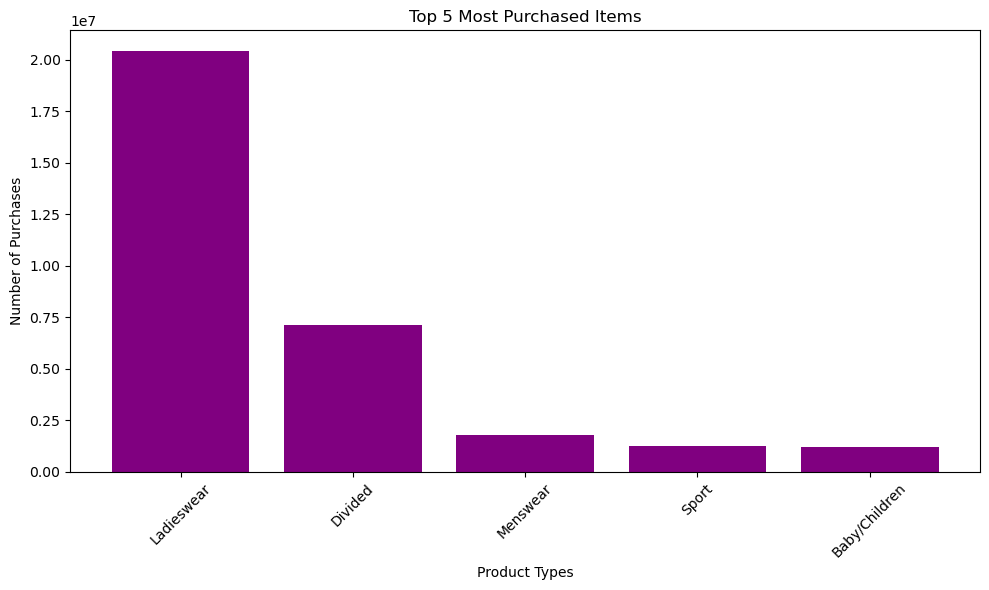

In [6]:
# view all columns and their null counts
#df.isnull().sum()

# Count purchases per article
top_articles = df['index_group_name'].value_counts().head(10)

# Plot
plt.figure(figsize=(10, 6))
plt.bar(top_articles.index.astype(str), top_articles.values, color='purple')
plt.title('Top 5 Most Purchased Items')
plt.xlabel('Product Types')
plt.ylabel('Number of Purchases')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



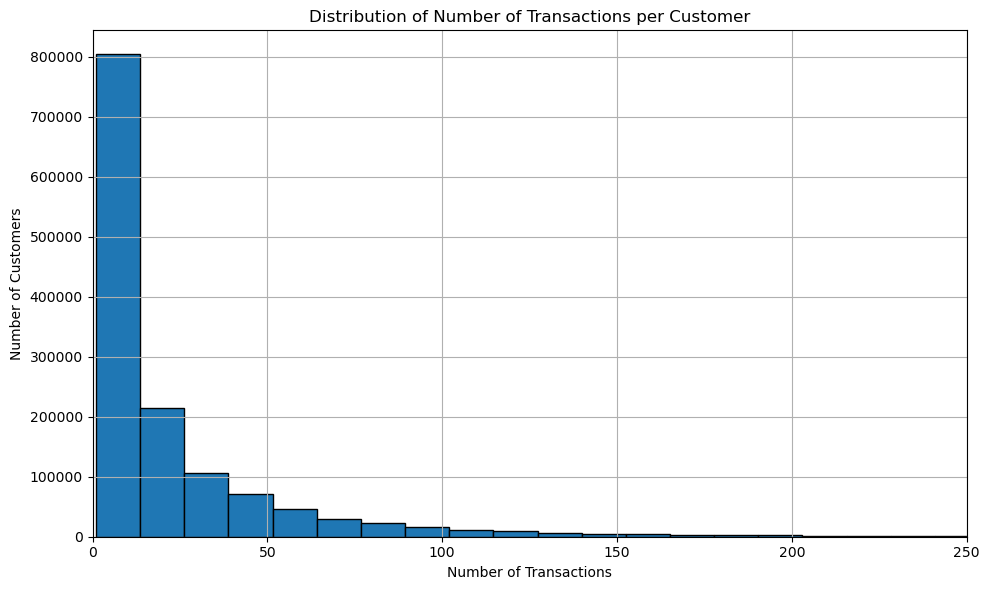

In [ ]:
transaction_counts = df['customer_id'].value_counts()

# Plot the histogram
plt.figure(figsize=(10, 6))
plt.hist(transaction_counts, bins=150, edgecolor='black')  # adjust bins as needed
plt.title('Distribution of Number of Transactions per Customer')
plt.xlabel('Number of Transactions')
plt.xlim(0, 250)  # Limit x-axis from 0 to 250
plt.ylabel('Number of Customers')
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
# drop the FN, Active, fashion_news_frequency columns
df = df.drop(columns=['FN', 'Active', 'fashion_news_frequency'])

# for the club_member_status column, drop the rows where the value is null or NaN or invalid
df = df[df['club_member_status'].notna()]

# for the age column, for rows with missing values, replace them with the median age
df['age'].fillna(df['age'].median(), inplace=True)

df.isnull().sum()


/var/folders/_0/dn5dccc95bqg3t95092yr1rr0000gn/T/ipykernel_2708/2176470804.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['age'].fillna(df['age'].median(), inplace=True)


t_dat                                0
customer_id                          0
article_id                           0
price                                0
sales_channel_id                     0
club_member_status                   0
age                                  0
postal_code                          0
product_code                         0
prod_name                            0
product_type_no                      0
product_type_name                    0
product_group_name                   0
graphical_appearance_no              0
graphical_appearance_name            0
colour_group_code                    0
colour_group_name                    0
perceived_colour_value_id            0
perceived_colour_value_name          0
perceived_colour_master_id           0
perceived_colour_master_name         0
department_no                        0
department_name                      0
index_code                           0
index_name                           0
index_group_no           

In [ ]:
# Step 1: Get all unique customer IDs
unique_ids = df['customer_id'].unique()

# Step 2: Randomly select a number of customer IDs (say, 100)
np.random.seed(42)  # Optional: ensures reproducibility
sample_ids = np.random.choice(unique_ids, size=100000, replace=False)

# Step 3: Filter the DataFrame to only include those customer IDs
df = df[df['customer_id'].isin(sample_ids)]

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2329349 entries, 97 to 31788318
Data columns (total 32 columns):
 #   Column                        Dtype  
---  ------                        -----  
 0   t_dat                         object 
 1   customer_id                   object 
 2   article_id                    int64  
 3   price                         float64
 4   sales_channel_id              int64  
 5   club_member_status            object 
 6   age                           float64
 7   postal_code                   object 
 8   product_code                  int64  
 9   prod_name                     object 
 10  product_type_no               int64  
 11  product_type_name             object 
 12  product_group_name            object 
 13  graphical_appearance_no       int64  
 14  graphical_appearance_name     object 
 15  colour_group_code             int64  
 16  colour_group_name             object 
 17  perceived_colour_value_id     int64  
 18  perceived_colour_value_na

In [ ]:
# now we need to filter the data to only include customers 
# aged 20-40 who have at least 40 transactions and to have only
#  transactions in the last 12 months, the latest t_dat is 2020-09-22 in the dataset


# convert t_date to datetime
df['t_dat'] = pd.to_datetime(df['t_dat'])
# filter the data to only include transactions in the last 12 months 
df = df[df['t_dat'] >= '2019-09-22']
print('The shape of the data after filtering for the most recent 12 months is ', df.shape)
# filter the data to only include customers aged 20-40
df = df[(df['age'] >= 20) & (df['age'] <=40)]
# filter the data to only include customers who have at least 40 transactions
# Get customer_ids with at least 40 transactions
eligible_customers = df['customer_id'].value_counts()
eligible_customers = eligible_customers[eligible_customers >= 40].index

# Filter df to only include those customers
df = df[df['customer_id'].isin(eligible_customers)]

print('The shape (aged 20-40 with at least 40 transactions in the most recent 12 months within the dataset) is', df.shape)
# sort by datetime and customer_id, then group the rows by customer_id
df = df.sort_values(by=['customer_id', 't_dat'])
df.head()

The shape of the data after filtering for the most recent 12 months is  (1100859, 32)
The shape (aged 20-40 with at least 40 transactions in the most recent 12 months within the dataset) is (292903, 32)


,t_dat,customer_id,article_id,price,sales_channel_id,club_member_status,age,postal_code,product_code,prod_name,...,department_name,index_code,index_name,index_group_no,index_group_name,section_no,section_name,garment_group_no,garment_group_name,detail_desc
17345084,2019-10-01,0010e8eb18f131e724d6997909af0808adbba057529edb...,757904002,0.025407,1,ACTIVE,25.0,6dcee1c9a053947b0bf4cb11a3c6e7015f2c5273c1bbaf...,757904,Maud Blanket,...,Scarves,C,Ladies Accessories,1,Ladieswear,65,Womens Big accessories,1019,Accessories,Large scarf in a soft weave with short fringes...
17345085,2019-10-01,0010e8eb18f131e724d6997909af0808adbba057529edb...,614848007,0.042356,1,ACTIVE,25.0,6dcee1c9a053947b0bf4cb11a3c6e7015f2c5273c1bbaf...,614848,Ellen Superpush (Andes) 2pk,...,Casual Lingerie,B,Lingeries/Tights,1,Ladieswear,61,Womens Lingerie,1017,"Under-, Nightwear",Push-up bras in soft cotton jersey with underw...
17995634,2019-10-17,0010e8eb18f131e724d6997909af0808adbba057529edb...,774953001,0.118627,1,ACTIVE,25.0,6dcee1c9a053947b0bf4cb11a3c6e7015f2c5273c1bbaf...,774953,Pitbull coat,...,Outwear,A,Ladieswear,1,Ladieswear,19,Womens Jackets,1007,Outdoor,"Fitted, knee-length coat in sturdy twill conta..."
17995635,2019-10-17,0010e8eb18f131e724d6997909af0808adbba057529edb...,456163048,0.033881,1,ACTIVE,25.0,6dcee1c9a053947b0bf4cb11a3c6e7015f2c5273c1bbaf...,456163,Woody,...,Jersey Basic,A,Ladieswear,1,Ladieswear,16,Womens Everyday Basics,1002,Jersey Basic,Wide top in sweatshirt fabric with a lined dra...
18221198,2019-10-24,0010e8eb18f131e724d6997909af0808adbba057529edb...,739687003,0.022017,1,ACTIVE,25.0,6dcee1c9a053947b0bf4cb11a3c6e7015f2c5273c1bbaf...,739687,Naomi Trouser,...,Kids Girl Jersey Fancy,H,Children Sizes 92-140,4,Baby/Children,76,Kids Girl,1005,Jersey Fancy,Treggings in sturdy jersey with an elasticated...


                               t_dat    article_id          price  \
count                         292903  2.929030e+05  292903.000000   
mean   2020-03-27 04:42:14.108561152  7.629020e+08       0.028796   
min              2019-09-22 00:00:00  1.087750e+08       0.000339   
25%              2019-12-25 00:00:00  7.195300e+08       0.016932   
50%              2020-04-05 00:00:00  7.962100e+08       0.025407   
75%              2020-06-24 00:00:00  8.423610e+08       0.033881   
max              2020-09-22 00:00:00  9.495510e+08       0.422034   
std                              NaN  1.246669e+08       0.019036   

       sales_channel_id            age   product_code  product_type_no  \
count     292903.000000  292903.000000  292903.000000    292903.000000   
mean           1.820132      28.116772  762901.952438       246.339290   
min            1.000000      20.000000  108775.000000        -1.000000   
25%            2.000000      24.000000  719530.000000       253.000000   
50%     

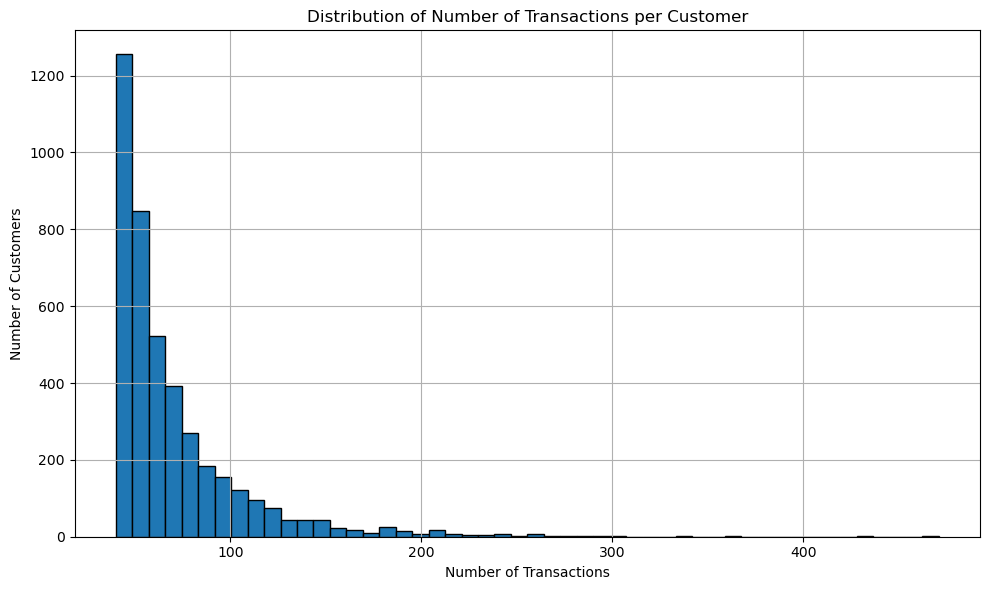

In [ ]:
print(df.describe())
# Count number of transactions per customer
transaction_counts = df['customer_id'].value_counts()

# Plot the histogram
plt.figure(figsize=(10, 6))
plt.hist(transaction_counts, bins=50, edgecolor='black')  # adjust bins as needed
plt.title('Distribution of Number of Transactions per Customer')
plt.xlabel('Number of Transactions')
plt.ylabel('Number of Customers')
plt.grid(True)
plt.tight_layout()
plt.show()

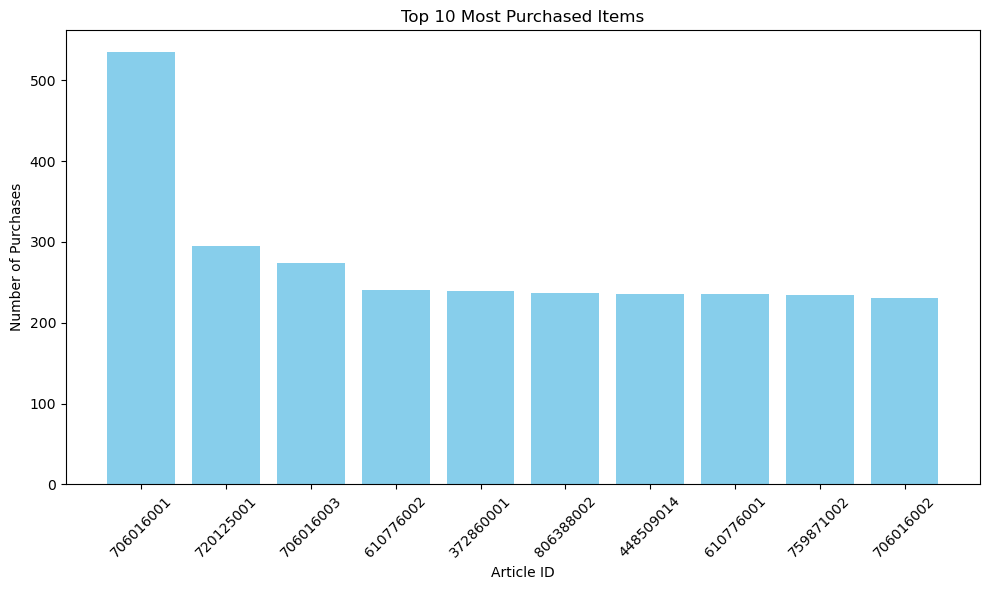

In [ ]:
# Count purchases per article
top_articles = df['article_id'].value_counts().head(10)

# Plot
plt.figure(figsize=(10, 6))
plt.bar(top_articles.index.astype(str), top_articles.values, color='skyblue')
plt.title('Top 10 Most Purchased Items')
plt.xlabel('Article ID')
plt.ylabel('Number of Purchases')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [ ]:
# create new csv file for the filtered data
#df.to_csv('/Users/aaronmcdonald/hm-fashion-recommender/data/processed/transactions_train_filtered.csv', index=False)

df.to_csv('data/processed/transactions_train_filtered.csv', index=False)


In [ ]:
# load transactions
#transactions = pd.read_csv(r'C:\Users\arlen\OneDrive\Documents\GitHub\hm-fashion-recommender\data\processed\transactions_train_filtered.csv')
transactions = pd.read_csv('data/processed/transactions_train_filtered.csv')


#sort transactions by id and then date so it is in chronological order
transactions['t_dat'] = pd.to_datetime(transactions['t_dat'])
transactions = transactions.sort_values(['customer_id', 't_dat']) 


In [ ]:
# split into train/test by date
max_date = transactions['t_dat'].max() #latest transaction
test_cutoff = max_date - timedelta(days=7)  #last 7 days for testing, before are for training

customer_groups = transactions.groupby('customer_id') #group by id to do transasctions per customer

# create train/test sequences for each customer
customer_sequences_train = []
customer_sequences_test = []
customer_ids_train = []
customer_ids_test = []

for customer_id, group in customer_groups:
    group = group.sort_values('t_dat')
    train = group[group['t_dat'] <= test_cutoff]['article_id'].tolist()
    test = group[group['t_dat'] > test_cutoff]['article_id'].tolist()
    if len(train) >= 7: #keeps only customers with at least 7 training transactions
        customer_sequences_train.append(train)
        customer_ids_train.append(customer_id)
        if len(test) > 0:
            customer_sequences_test.append(test)
            customer_ids_test.append(customer_id)

In [ ]:
# generate sliding window sequences
window_size = 7
target_size = 7
X = [] #input sequences
Y = [] #output sequences
for seq in customer_sequences_train:
    if len(seq) < window_size + target_size: #skips if sequence is too short
        continue
    for i in range(len(seq) - window_size - target_size + 1): #creates sliding windows for each possible position with window size as input and target size as output
        X.append(seq[i:i+window_size])
        Y.append(seq[i+window_size:i+window_size+target_size])



In [ ]:
# label encode the article IDs
all_articles = sorted(set([a for seq in X+Y for a in seq])) #sorts all unique IDs
article_to_idx = {article: idx for idx, article in enumerate(all_articles)} #maps each article to a unique integer
idx_to_article = {idx: article for article, idx in article_to_idx.items()} #reverse mapping from integer to article ID
X_encoded = [[article_to_idx[a] for a in seq] for seq in X] #input sequences encoded as integers
Y_encoded = [[article_to_idx[a] for a in seq] for seq in Y] #output sequences encoded as integers

In [ ]:
#Checking the results
print(f"Number of customers in train: {len(customer_sequences_train)}")
print(f"First train sequence: {customer_sequences_train[0]}")
print(f"First encoded X: {X_encoded[0]}")
print(f"First encoded Y: {Y_encoded[0]}")

Number of customers in train: 4201
First train sequence: [757904002, 614848007, 774953001, 456163048, 739687003, 739687007, 759154001, 757005003, 772773001, 772773008, 778064004, 750422023, 516859008, 799428003, 562245046, 827370003, 827370001, 372860001, 649551007, 762896007, 852513004, 824490001, 620081001, 795675001, 856304002, 707269003, 719530003, 752689002, 706016003, 843685003, 706016001, 827968002, 843685001, 706016006, 843685001, 843685003, 687704039, 237347055, 843685003, 779546001, 841260008, 840947002, 429313002, 841182003, 821163010, 837741002, 861608003, 570319050, 562613010, 841383002, 762846006, 828067001, 883033001, 399256001]
First encoded X: [13463, 3723, 15571, 817, 11178, 11179, 13586]
First encoded Y: [13320, 15375, 15378, 15904, 12377, 1382, 18827]


In [ ]:

# prepare test data, use same sliding logic

X_test = [] 
Y_test = []
for seq in customer_sequences_test:  
    if len(seq) < window_size + target_size:
        continue
    for i in range(len(seq) - window_size - target_size + 1):
        X_test.append(seq[i:i+window_size])
        Y_test.append(seq[i+window_size:i+window_size+target_size])

# encode test sequences using same mapping from training
X_test_encoded = [[article_to_idx.get(a, 0) for a in seq] for seq in X_test]  
Y_test_encoded = [[article_to_idx.get(a, 0) for a in seq] for seq in Y_test]
 
import torch

# convert lists to tensors
X_train_tensor = torch.tensor(X_encoded, dtype=torch.long)
Y_train_tensor = torch.tensor(Y_encoded, dtype=torch.long)
X_test_tensor = torch.tensor(X_test_encoded, dtype=torch.long)
Y_test_tensor = torch.tensor(Y_test_encoded, dtype=torch.long)
 
# save final tensor and mapping, to be later fed into model
torch.save({
    'X_train': X_train_tensor,
    'Y_train': Y_train_tensor,
    'X_test': X_test_tensor,
    'Y_test': Y_test_tensor,
    'article_to_idx': article_to_idx,
    'idx_to_article': idx_to_article
}, 'data/processed/final_lstm_data.pth')  

print("Data preparation complete. Saved to 'data/processed/final_lstm_data.pth'")



Data preparation complete. Saved to 'data/processed/final_lstm_data.pth'
